# 🪙 **Demo: Contagem e Classificação de Moedas**

Este Notebook demonstra como utilizar técnicas de processamento digital de imagens para identificar moedas em uma foto, calcular sua área em pixels e estimar o valor total somado.

### 1. Problema

O desafio consiste em extrair informações quantitativas de uma imagem digital no qual primeiro é necessário separar o que é moeda do que é fundo, medir o tamanho de cada objeto e aplicar uma regra de decisão para classificar o valor de cada moeda.

### 2. Importação das bibliotecas

In [99]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests

### 3. Importação das imagens

O primeiro passo é carregar as imagens aqui também será realizada a extração de duas moedas da imagem para análise individual.

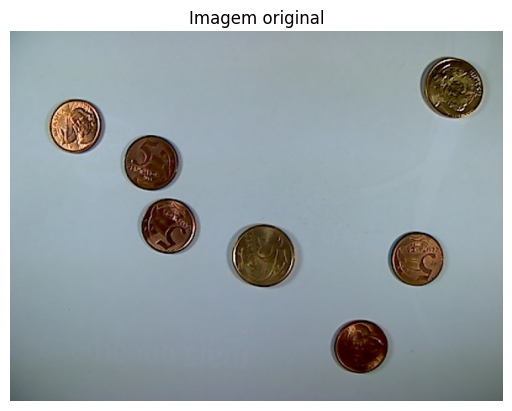

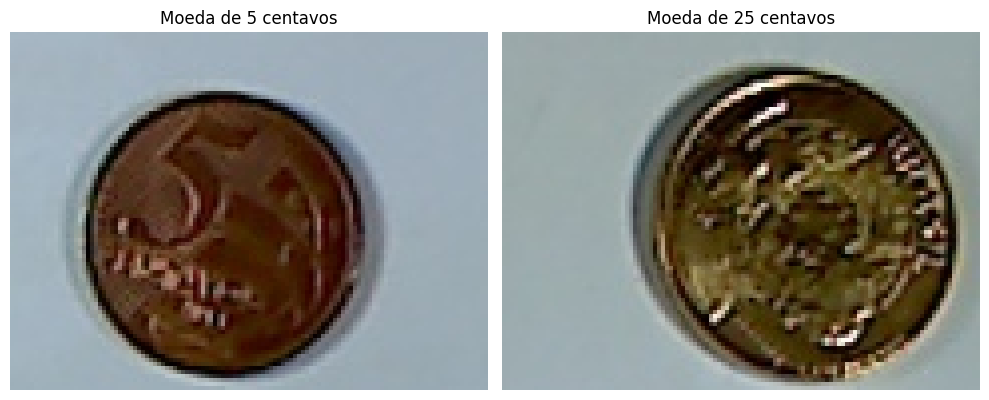

In [100]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

moeda_1 = 75
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"

url = url_base.format(value=moeda_1)
filename = download_image(url)
img_1 = mpimg.imread(filename).astype('uint8')
plt.title("Imagem original")
plt.axis('off')
plt.imshow(img_1)
plt.show()

#Selecionando a janela de interesse para a moeda de 5 centavos
y_start, y_end = 120, 210
x_start, x_end = 130, 250

#Realizando o crop usando fatiamento de array
img_5_centavos = img_1[y_start:y_end, x_start:x_end]

plt.figure(figsize=(10, 5)) 

plt.subplot(1, 2, 1)
plt.title("Moeda de 5 centavos")
plt.axis('off')
plt.imshow(img_5_centavos, cmap='gray')

#Selecionando a janela de interesse para a moeda de 25 centavos
#IMPORTANTE: a janela das duas moedas tem o mesmo tamanho
y_start, y_end = 25, 115 
x_start, x_end = 500, 620
img_25_centavos = img_1[y_start:y_end, x_start:x_end]

plt.subplot(1, 2, 2)
plt.title("Moeda de 25 centavos")
plt.axis('off')
plt.imshow(img_25_centavos, cmap='gray')

plt.tight_layout()
plt.show()

### 4. Segmentação e Limpeza

Aqui são isoladas cada moeda e para isso é utilizado o Método de Otsu onde ele analisa o histograma da imagem e busca o valor que maximiza a separação entre o fundo e o objeto. Além disso, um kernel de 15 é suficiente para fechar pequenos reflexos dentro da moeda enquanto, m kernel de 31 é maior, usado na abertura para garantir que mesmo ruídos grandes ou sombras na borda da moeda sejam eliminados, deixando apenas o corpo principal da moeda para a contagem.

[Discussão interessante no Stack Overflow](https://stackoverflow.com/questions/71775002/why-opencv-cv2-morphologyex-operations-shift-images-in-one-direction-during-it)

In [101]:
def seg_and_postprocessing(img, k_cl, k_op):
    #Binarização Automática de Otsu
    #O parâmetro (255 - img_gray) inverte a imagem: moedas ficam brancas (255) e o fundo preto (0)
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    #Criando os kernels
    kernel_cl = np.ones((k_cl, k_cl), np.uint8) 
    kernel_op = np.ones((k_op, k_op), np.uint8)

    #Aplicando o fechamento para tirar buracos de dentro das moedas
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    #Aplicando a abertura para limpar sujeira do fundo 
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.title("Imagem binarizada")
    plt.imshow(binr, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Imagem após fechamento")
    plt.imshow(close, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Imagem após abertura")
    plt.imshow(open, cmap='gray')
    plt.axis('off')
    plt.show()

    return open

### 5. Área de cada moeda

Depois de segmentar as moedas é necessário o cálculo da área dos pixels de cada objeto para fazer a distinção entre cada valor de moeda.

In [102]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

### 6. Classificação por Área e Soma

Nesta etapa, é criada uma função que converte a imagem para grayscale, aplica as funções descritas anteriormente e depois faz a classificação da moeda com base no número de pixels do objeto segmentado para isso foram escolhidos três intervalos: p < 3500: a moeda é de 10 centavos; p > 4600: a moeda é de 25 centavos; e qualquer área fora desses valores é classificada como moeda de 5 centavos. Para testar essas regras foram usadas individualmente as imagens das moedas de 5 e 25 centavos.

In [103]:
def calc_area_label(img, titulo):
  img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
  seg_img = seg_and_postprocessing(img_gray, 15, 31)

  #num labels: número total de rótulos encontrados (incluindo o fundo)
  #labels: imagem onde cada pixel tem o valor do rótulo ao qual pertence
  #stats: matriz onde cada linha tem as estatísticas do rótulo (não utilizado nesse notebook)
  #centroids: matriz onde cada linha tem as coordenadas do centróide do rótulo
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(seg_img, 4)

  plt.figure(figsize=(10,4))
  plt.subplot(1,2,1)
  plt.title("Imagem segmentada")
  plt.imshow(labels)
  plt.axis('off')

  list_npixels = calc_npixels_label(labels, num_labels)

  soma = 0
  for n, p in enumerate(list_npixels):
    #são utilizados os centróides para posicionar o texto do valor da moeda
    x = int(centroids[n+1][0])
    y = int(centroids[n+1][1])

    #moeda de 10 centavos: área menor que 3500 pixels
    #moeda de 25 centavos: área maior que 4600 pixels
    #moeda de 5 centavos: área entre 3500 e 4600 pixels
    if p < 3500:
      soma += 10
      cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
      soma += 25
      cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
      soma += 5
      cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  plt.subplot(1,2,2)
  plt.title("Imagem com rótulos")
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print(titulo)
  print('Número de moedas encontrada:', len(list_npixels))
  print('Números de pixels:', list_npixels)
  print('Valor total das moedas:', soma)

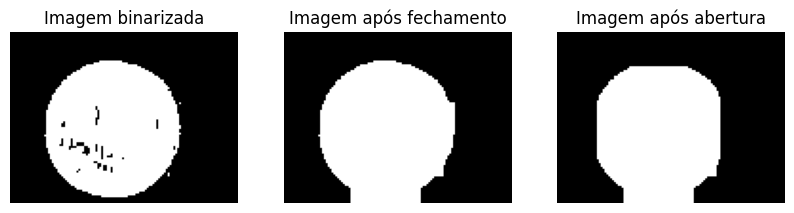

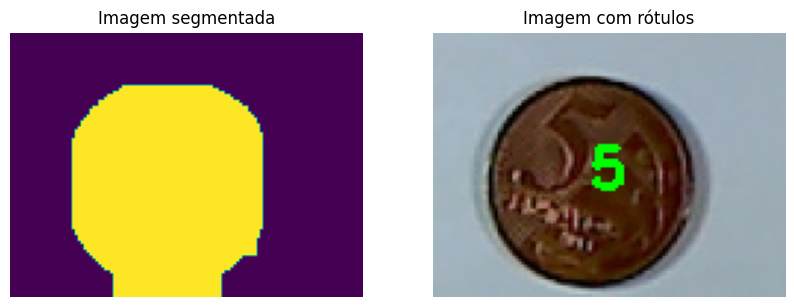

Moeda de 5 centavos
Número de moedas encontrada: 1
Números de pixels: [4065]
Valor total das moedas: 5


In [104]:
calc_area_label(img_5_centavos, "Moeda de 5 centavos")

No caso da moeda de 5 centavos, o número de pixels encontrado foi de 4065 e consequentemente a classificação foi correta. 

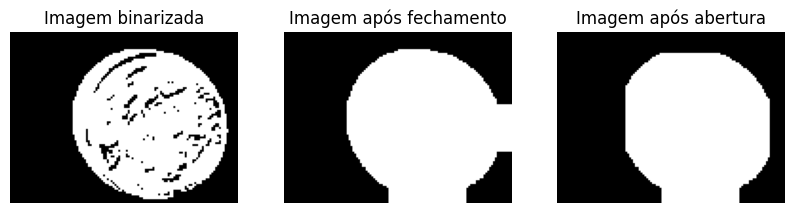

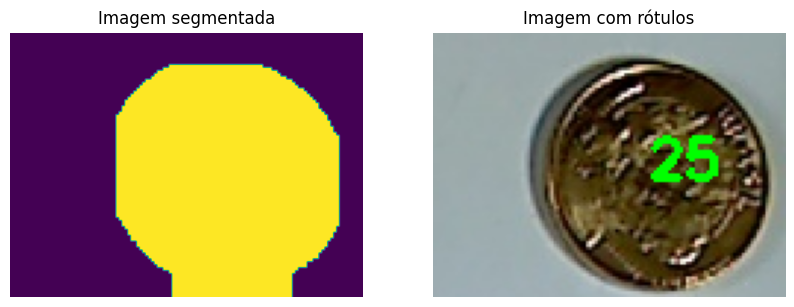

Moeda de 25 centavos
Número de moedas encontrada: 1
Números de pixels: [5091]
Valor total das moedas: 25


In [105]:
calc_area_label(img_25_centavos, "Moeda de 25 centavos")

Dessa vez com a imagem da moeda de 25 centatos o valor da área foi de 5089 o que novamente é maior que 4600 pixels, ou seja, a moeda foi classificada corretamente como de 25 centavos.

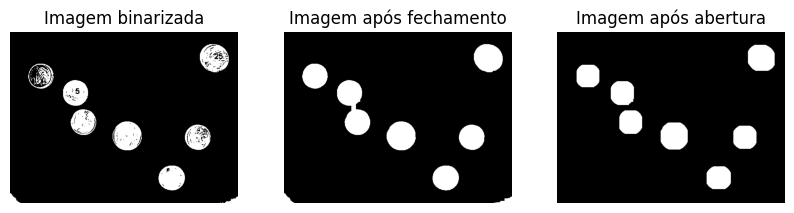

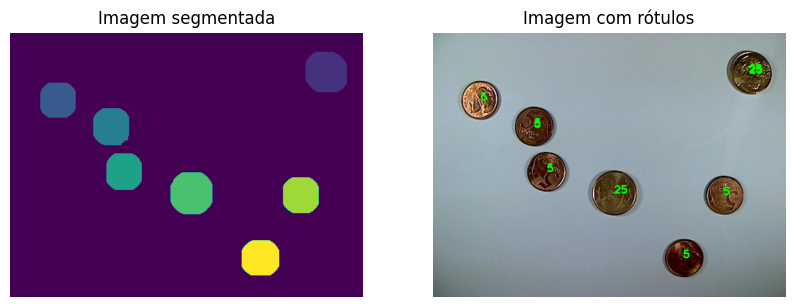

Imagem original
Número de moedas encontrada: 7
Números de pixels: [4803, 3636, 3863, 3786, 5014, 3766, 3859]
Valor total das moedas: 75


In [106]:
calc_area_label(img_1, "Imagem original")

Por último, foi testada a imagem original, sem realizar o crop, para verificar se o código é capaz de identificar as moedas mesmo com a presença de outras informações na imagem. O resultado foi satisfatório, o código conseguiu identificar as moedas e calcular o valor total corretamente.

### Referências úteis

[Material sobre a Binarização de Otsu](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)

[Material sobre opening e closing](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)

[Material sobre como extrair dados de formas geométricas](https://pyimagesearch.com/2021/02/22/opencv-connected-component-labeling-and-analysis/)